In [24]:
!pip install langchain_openai langchain_community langchain hnswlib langchain_groq faiss-cpu wikipedia

In [ ]:
%env GROQ_API_KEY=YOUR_API_KEY

In [26]:
import json
import requests
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph
from typing import TypedDict, List
import os
from langchain_groq import ChatGroq
from typing import TypedDict, List
from langchain_core.messages import HumanMessage
import wikipedia
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from operator import add as add_messages
from langgraph.graph import StateGraph, END

In [27]:
# СКАЧИВАНИЕ ДАННЫХ

wikipedia.set_lang("ru")

# Список статей для загрузки
topics = [
    "Солнечная система",
    "Искусственный интеллект",
    "Машинное обучение",
    "Python",
    "Нейронная сеть",
    "Информатика",
    "Алгоритм",
    "Наука о данных",
    "Глубокое обучение"
]

# Загружаем статьи и сохраняем в JSON
documents = []
for topic in topics:
    try:
        page = wikipedia.page(topic)
        doc = {
            "title": page.title,
            "text": page.content,
            "url": page.url
        }
        documents.append(doc)
        print(f"Загружена статья: {page.title}")
    except Exception as e:
        print(f"Ошибка загрузки {topic}: {e}")

# Сохраняем в JSON файл
with open("wikipedia_articles.json", "w", encoding="utf-8") as f:
    json.dump(documents, f, ensure_ascii=False, indent=2)

print(f"Сохранено {len(documents)} статей в wikipedia_articles.json")

# Загружаем из JSON файла
with open("wikipedia_articles.json", "r", encoding="utf-8") as f:
    loaded_documents = json.load(f)

# Преобразуем в документы LangChain
langchain_docs = []
for item in loaded_documents:
    doc = Document(
        page_content=item['text'],
        metadata={"title": item['title'], "url": item.get('url', '')}
    )
    langchain_docs.append(doc)

Загружена статья: Солнечная система
Загружена статья: Искусственный интеллект
Загружена статья: Машинное обучение
Загружена статья: Python
Загружена статья: Нейронная сеть
Загружена статья: Информатика
Загружена статья: Алгоритм
Загружена статья: Наука о данных
Загружена статья: Глубокое обучение
Сохранено 9 статей в wikipedia_articles.json


In [ ]:
page = wikipedia.page("Python")
print(page.content)

Python (МФА: [ˈpaɪθ(ə)n]; в русском языке встречаются названия пито́н или па́йтон) — мультипарадигменный высокоуровневый язык программирования общего назначения с динамической строгой типизацией и автоматическим управлением памятью, ориентированный на повышение производительности разработчика, читаемости кода и его качества, а также на обеспечение переносимости написанных на нём программ. Язык является полностью объектно-ориентированным в том плане, что всё является объектами. Необычной особенностью языка является выделение блоков кода отступами. Синтаксис ядра языка минималистичен, за счёт чего на практике редко возникает необходимость обращаться к документации. Поскольку Python является интерпретируемым языком, он также является и скриптовым. Недостатками языка являются зачастую более низкая скорость работы и более высокое потребление памяти написанными на нём программами по сравнению с аналогичным кодом, написанным на компилируемых языках, таких как C или C++.
Python является мульти

In [28]:
# ЗАГРУЗКА МОДЕЛИ ЭМБЕДДИНГОВ

# Нарезка на чанки
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = text_splitter.split_documents(langchain_docs)

embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-base",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for doc in docs:
  print(doc.page_content, end = "\n==\n")

Иску́сственный интелле́кт (англ. artificial intelligence; AI), также ИИ, искусственный ра́зум, в самом широком смысле — комплекс инструментов, позволяющих решать задачи уровня человеческого интеллекта (такие как восприятие, обучение, рассуждение, решение проблем и принятие решений) и реализованных машинами, в частности компьютерными системами. Это направление исследований в области компьютерных наук, которая разрабатывает и изучает методы и программное обеспечение, позволяющие машинам
==
и программное обеспечение, позволяющие машинам воспринимать окружающую среду и использовать обучение и интеллект для выполнения действий, которые максимально увеличивают их шансы на достижение поставленных целей. Такие машины можно назвать искусственным интеллектом. В то же время не следует путать понятия ИИ и больших языковых моделей (БЯМ/LLM): если ИИ — это область компьютерных наук, охватывающая решение широкого круга интеллектуальных задач, то БЯМ/LLM — это лишь один (хоть и самый
==
задач, то БЯМ/

In [29]:
# ВЕКТОРНОЕ ХРАНИЛИЩЕ
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [30]:
system_prompt = """Вы являетесь помощником RAG, который отвечает на вопросы, строго основанные на предоставленных статьях Википедии.
Для поиска информации в википедии используй соответствующий инструмент.

Также вы можете вычислять арифметические выражения. Для вычисления выражения используйте соответствующий инструмент.

## ВАЖНЫЕ ПРАВИЛА - ВЫ ДОЛЖНЫ СОБЛЮДАТЬ:

1. ** ИСПОЛЬЗУЙТЕ ТОЛЬКО ПРЕДОСТАВЛЕННЫЙ КОНТЕКСТ **: Ваши ответы должны основываться ИСКЛЮЧИТЕЛЬНО на информации, полученной из загруженных статей Википедии. НЕ используйте свои внутренние знания или данные об обучении.

2. ** НИКАКИХ ВНЕШНИХ ЗНАНИЙ **: Даже если вы "знаете" ответ из своего обучения, вы НЕ ДОЛЖНЫ использовать его, если он не указан в полученных документах.

3. ** ОБРАБОТАЙТЕ НЕДОСТАЮЩУЮ ИНФОРМАЦИЮ **: Если информация отсутствует в извлеченных документах, вы ДОЛЖНЫ ответить одной из следующих фраз:
   - "Основываясь на доступных статьях Википедии, я не могу найти информацию по [теме]".
   - "Предоставленные статьи Википедии не содержат информации о [конкретном запросе]".
   - "В загруженных статьях недостаточно информации, чтобы ответить на этот вопрос".

4. **УКАЗЫВАЙТЕ СВОИ ИСТОЧНИКИ **: При предоставлении информации всегда указывайте, какую часть контекста вы используете. Например:
   - "Согласно статье в Википедии по [теме]..."
   - "В найденном документе утверждается, что..."
   - "Как указано в предоставленной статье..."

5. ** НИКАКИХ ПРЕДПОЛОЖЕНИЙ **: Никогда не стройте предположений, не предполагайте и не добавляйте информацию, выходящую за рамки того, что указано в контексте. Если контекст неполон, обратите внимание на это ограничение.

6. **ЦИТИРУЙТЕ ТОЧНО**: При прямом цитировании используйте кавычки и убедитесь, что цитата точно соответствует источнику.

7. **ПРОВЕРКА КОНТЕКСТА**: Прежде чем ответить, спросите себя: "Присутствует ли эта информация в извлеченных документах?" Если ответ отрицательный, НЕ предоставляйте информацию.

8. **ПРАВИЛА ДЛЯ АРИФМЕТИЧЕСКИХ ВЫЧИСЛЕНИЙ**:
   - Если пользователь просит вычислить арифметическое выражение, ОБЯЗАТЕЛЬНО вызови инструмент `calc_tool`
   - После получения результата от инструмента, ВСЕГДА форматируй ответ строго по шаблону: `выражение = результат`
   - Примеры правильного форматирования:
     * Пользователь: "сколько будет 2+2?" → Ваш ответ: `2+2 = 4`
     * Пользователь: "вычисли 15 * 3" → Ваш ответ: `15 * 3 = 45`
     * Пользователь: "посчитай (10+5)/3" → Ваш ответ: `(10+5)/3 = 5.0`
   - Если инструмент возвращает ошибку (например, деление на ноль или неверное выражение), сообщи об этом: `выражение = ОШИБКА: [описание ошибки]`
   - НЕ добавляй никаких дополнительных комментариев к результату вычисления
   - НЕ используй свои знания для вычисления - ВСЕГДА вызывай инструмент

9. **РАЗДЕЛЕНИЕ ТИПОВ ЗАПРОСОВ**:
   - Для запросов о фактах → используй `retrieve_tool` для поиска в Википедии
   - Для арифметических вычислений → используй `calc_tool`
   - Если запрос смешанный (например, "найди информацию о Париже и посчитай 5*7") → сначала выполни поиск, затем вычисления, и объедини результаты"""


In [82]:
# ОПРЕДЕЛЕНИЕ И СБОРКА ГРАФА (ВАРИАНТ 1)

llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
# Регаем отдельную llm для рефлексии
reflection_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.3)

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    was_reflection : int
    counter : int

@tool
def calc_tool(expression: str):
    """ Вычисляет математическое выражение """

    try:
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"Ошибка: {e}"

@tool
def retrieve_tool(query : str):
    """ Функция по запросу ищет и возвращает информацию из википедии"""
    retrieved_docs = retriever.invoke(query)

    if not retrieved_docs:
        return "ИНФОРМАЦИЯ НЕ НАЙДЕНА: По вашему запросу не найдено ни одной статьи в Википедии."

    results = []
    for i, doc in enumerate(retrieved_docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)


tools = [retrieve_tool, calc_tool]
tools_dict = {our_tool.name: our_tool for our_tool in tools}

llm = llm.bind_tools(tools)


def reflect_on_answer(state: AgentState) -> AgentState:
    """Рефлексия с четкой структурой JSON"""

    print("REFLECTION STARTED")

    last_message = state['messages'][-1].content
    query = state['messages'][0].content

    reflection_prompt = f"""Ты - критик, оценивающий качество ответа на вопрос.

Исходный вопрос: {query}
Полученный ответ: {last_message}

Проанализируй ответ и верни ТОЛЬКО JSON в следующем формате:
{{
    "needs_improvement": true/false,
    "confidence": 0-100,
    "missing_elements": ["список", "чего", "не хватает"],
    "improved_query": "уточненный запрос для поиска (если needs_improvement=true, иначе пустая строка)",
    "reasoning": "краткое объяснение решения"
}}

Правила оценки:
- needs_improvement=true если: информация не найдена, ответ слишком общий, есть противоречия
- needs_improvement=false если: ответ полный и точный
- confidence - насколько ты уверен в оценке (0-100)"""

    if state['was_reflection'] >= 1:
      return {'messages': [], 'counter': state['counter'], 'was_reflection': 2}

    try:
        reflection = reflection_llm.invoke([HumanMessage(content=reflection_prompt)])

        # Собрать и парсить JSON
        content = reflection.content
        start_idx = content.find('{')
        end_idx = content.rfind('}') + 1
        if start_idx != -1 and end_idx != 0:
            json_str = content[start_idx:end_idx]
            result = json.loads(json_str)

            print(f"Рефлексия: needs_improvement={result.get('needs_improvement')}, уверенность={result.get('confidence')}%")

            # Проверяем уверенность и необходимость улучшения
            if result.get('needs_improvement') and result.get('confidence', 0) > 70:
                improved_query = result.get('improved_query', '')
                if improved_query:
                    return {
                        'messages': [HumanMessage(
                            content=f"Уточненный запрос: {improved_query}, если информация не будет найдена, не вызывай инструмент повторно с другим запросом, а сообщи о том, что информация не найдена"
                          )],
                        'counter': state['counter'],
                        'was_reflection': 1
                    }

            # Если улучшение не требуется или низкая уверенность
            return {'messages': [], 'counter': state['counter'], 'was_reflection': 2}

    except Exception as e:
        print(f"Ошибка парсинга рефлексии: {e}")
        return {'messages': [], 'counter': state['counter'], 'was_reflection': 2}



def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    print("CALL LLM CALLED")

    current_counter = state.get('counter', 0)
    was_reflection = state.get('was_reflection', 0)
    if current_counter >= 3:
        print("Лимит запросов превышен (counter >= 3)")
        error_message = """
        Извините, я не смог найти информацию в Википедии после нескольких попыток.
        Пожалуйста, уточните вопрос или попробуйте другую формулировку."""

        return {
            'messages': [AIMessage(content=error_message)],
            'counter': current_counter
        }

    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm.invoke(messages)

    return {
        'messages': [message],
        'counter': current_counter
    }

def should_continue(state: AgentState):
    """Check if the last message contains tool calls."""
    print("SHOULD CONTINUE CALLED")
    result = state['messages'][-1]
    if state['counter'] >= 3:
      return "end"
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""
    print("TAKE ACTION CALLED")
    tool_calls = state['messages'][-1].tool_calls
    results = []

    current_counter = state.get('counter', 0)

    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}, expression: {t['args'].get('expression', 'No expression')}")
        if t['name'] == 'retrieve_tool':
            current_counter += 1

        if not t['name'] in tools_dict:
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."
        else:
            if t['name'] == 'calc_tool':
              result = tools_dict[t['name']].invoke(t['args'].get('expression', ''))
            elif t['name'] == 'retrieve_tool':
              result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")

        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")

    if state.get('was_reflection', 0) == 1:
      return {'messages': results, 'counter': current_counter, 'was_reflection': 2}
    return {'messages': results, 'counter': current_counter}

graph = StateGraph(AgentState)
graph.add_node("llm", call_llm)
graph.add_node("retriever_agent", take_action)
graph.add_node("reflection", reflect_on_answer)

graph.add_conditional_edges(
    "llm", # Из какого узла
    should_continue, # Условие
    {True: "retriever_agent", False: "reflection", "end" : END}
)

graph.add_conditional_edges(
    "reflection", # Из какого узла
    lambda state: False if state['was_reflection'] == 2 else True, # Условие
    {True: "llm", False: END}
)

graph.add_edge("retriever_agent", "llm")
graph.set_entry_point("llm")
# graph.add_edge("llm", END)

rag_agent = graph.compile()


def running_agent(query):
    print("\n=== RAG AGENT===")
    messages = [HumanMessage(content=query)]

    result = rag_agent.invoke({"messages": messages, 'counter' : 0, "was_reflection" : False})

    print("\n=== ANSWER ===")
    print(result['messages'][-1].content)



In [83]:
query = "Когда и кем был создан язык программирования Python?"
running_agent(query)


=== RAG AGENT===
CALL LLM CALLED
SHOULD CONTINUE CALLED
TAKE ACTION CALLED
Calling Tool: retrieve_tool with query: Python programming language created when by whom, expression: No expression
Result length: 1382
Tools Execution Complete. Back to the model!
CALL LLM CALLED
SHOULD CONTINUE CALLED
REFLECTION STARTED
Рефлексия: needs_improvement=False, уверенность=95%

=== ANSWER ===
Согласно статье в Википедии, идея создания языка появилась в конце 1980‑х годов, а разработка его реализации началась в 1989 году сотрудником голландского института CWI Гвидо ван Россумом.


In [84]:
query = "Что такое сингулярное разложение матрицы?"
running_agent(query) # retrieve_tool вызывается дважды из за рефлексии. Второй раз вызывается с другим query.


=== RAG AGENT===
CALL LLM CALLED
SHOULD CONTINUE CALLED
TAKE ACTION CALLED
Calling Tool: retrieve_tool with query: сингулярное разложение матрицы, expression: No expression
Result length: 251
Tools Execution Complete. Back to the model!
CALL LLM CALLED
SHOULD CONTINUE CALLED
REFLECTION STARTED
Рефлексия: needs_improvement=True, уверенность=95%
CALL LLM CALLED
SHOULD CONTINUE CALLED
TAKE ACTION CALLED
Calling Tool: retrieve_tool with query: сингулярное разложение матрицы определение формула примеры применение, expression: No expression
Result length: 700
Tools Execution Complete. Back to the model!
CALL LLM CALLED
SHOULD CONTINUE CALLED
REFLECTION STARTED

=== ANSWER ===
Основываясь на доступных статьях Википедии, я не могу найти информацию по сингулярному разложению матрицы.


In [80]:
query = "Вычисли 5 + 2 * 3 * 2"
running_agent(query)


=== RAG AGENT===
CALL LLM CALLED
SHOULD CONTINUE CALLED
TAKE ACTION CALLED
Calling Tool: calc_tool with query: No query provided, expression: 5 + 2 * 3 * 2
Result length: 2
Tools Execution Complete. Back to the model!
CALL LLM CALLED
SHOULD CONTINUE CALLED
REFLECTION STARTED
Рефлексия: needs_improvement=False, уверенность=95%

=== ANSWER ===
5 + 2 * 3 * 2 = 17


In [ ]:
# =================================================================================================

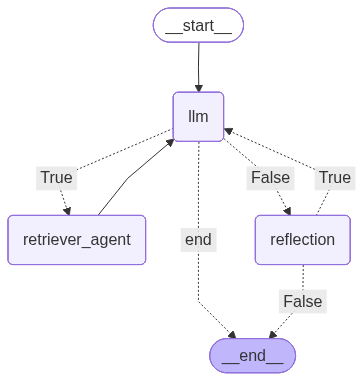

In [81]:
from IPython.display import Image, display
display(Image(rag_agent.get_graph().draw_mermaid_png()))